In [49]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


#BAGIAN A: Membaca dan Menampilkan Citra


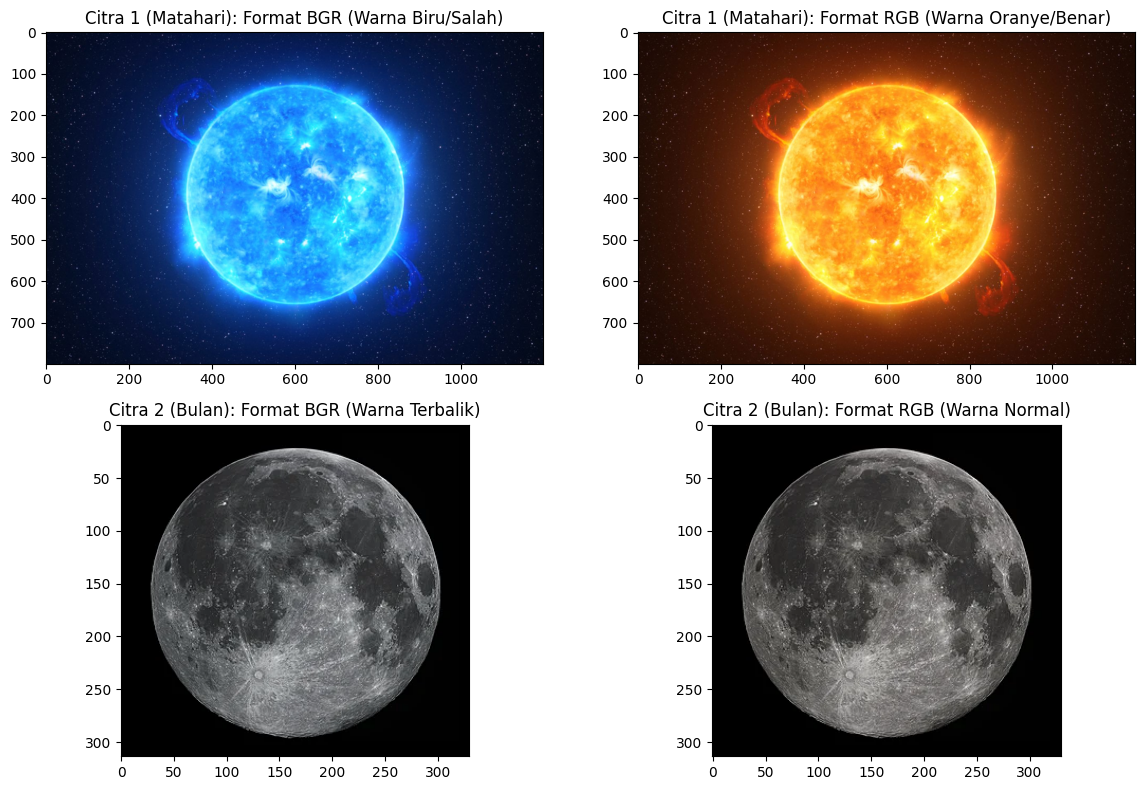

=== METADATA CITRA ASLI 1 (Matahari) ===
Ukuran Citra (Shape) : (800, 1200, 3)
Tipe Data Citra      : uint8
Nilai Minimum Pixel  : 0
Nilai Maksimum Pixel : 255

=== METADATA CITRA ASLI 2 (Bulan) ===
Ukuran Citra (Shape) : (314, 330, 3)
Tipe Data Citra      : uint8
Nilai Minimum Pixel  : 0
Nilai Maksimum Pixel : 255



In [50]:
# Membaca file gambar matahari (image1) dan bulan (image2) dari folder lokal
img1 = cv.imread("image1.jpg")
img2 = cv.imread("image2.webp") # Changed to .webp

if img1 is None or img2 is None:
    raise FileNotFoundError("File 'image1.jpg' atau 'image2.webp' tidak ditemukan di folder atau tidak valid. "
                            "Pastikan Anda telah memindahkan foto matahari dan bulan ke folder kerja Anda dan formatnya benar!")

# Konversi ruang warna BGR bawaan OpenCV ke RGB bawaan Matplotlib
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# Plotting Bagian A: Menampilkan perbedaan penafsiran warna matriks
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(img1)
axes[0, 0].set_title("Citra 1 (Matahari): Format BGR (Warna Biru/Salah)")
axes[0, 1].imshow(img1_rgb)
axes[0, 1].set_title("Citra 1 (Matahari): Format RGB (Warna Oranye/Benar)")

axes[1, 0].imshow(img2)
axes[1, 0].set_title("Citra 2 (Bulan): Format BGR (Warna Terbalik)")
axes[1, 1].imshow(img2_rgb)
axes[1, 1].set_title("Citra 2 (Bulan): Format RGB (Warna Normal)")
plt.tight_layout()
plt.show()

# Menampilkan Metadata Numerik Eksperimen
for idx, img in enumerate([img1, img2], 1):
    nama_objek = "Matahari" if idx == 1 else "Bulan"
    print(f"=== METADATA CITRA ASLI {idx} ({nama_objek}) ===")
    print(f"Ukuran Citra (Shape) : {img.shape}")
    print(f"Tipe Data Citra      : {img.dtype}")
    print(f"Nilai Minimum Pixel  : {img.min()}")
    print(f"Nilai Maksimum Pixel : {img.max()}\n")

BAGIAN B: Resize Citra

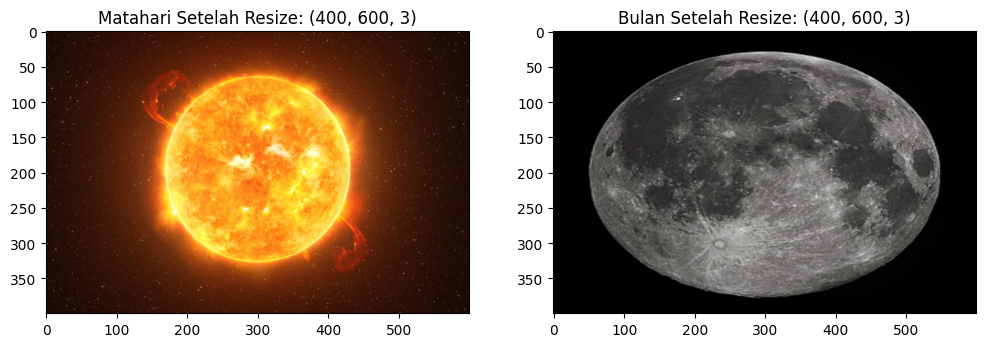

In [51]:
# Menyamakan dimensi spasial kedua matriks gambar menjadi 600 x 400 pixel
target_size = (600, 400)
img1_resize = cv.resize(img1_rgb, target_size)
img2_resize = cv.resize(img2_rgb, target_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img1_resize)
axes[0].set_title(f"Matahari Setelah Resize: {img1_resize.shape}")
axes[1].imshow(img2_resize)
axes[1].set_title(f"Bulan Setelah Resize: {img2_resize.shape}")
plt.show()

BAGIAN C: Image Blending (Pencampuran Matriks)

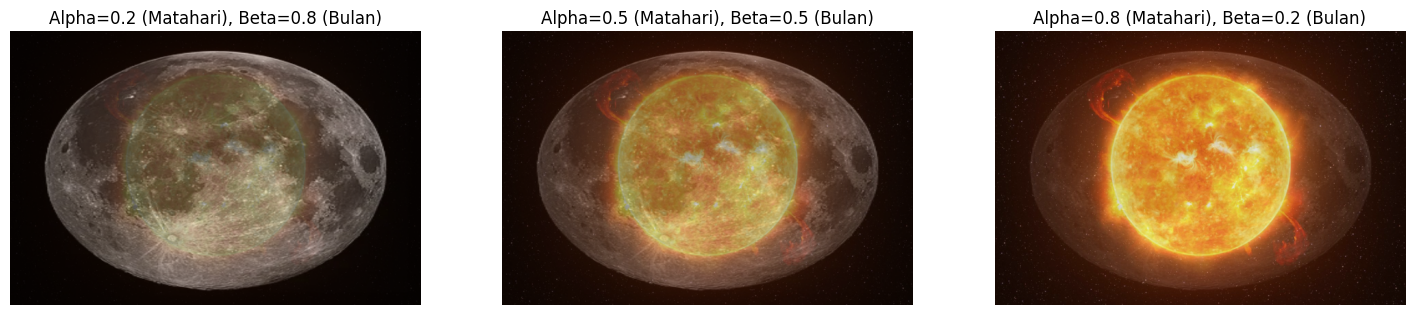

In [52]:
# Melakukan perpaduan linear antara objek matahari dan bulan
blends = [
    (0.2, 0.8, cv.addWeighted(img1_resize, 0.2, img2_resize, 0.8, 0)),
    (0.5, 0.5, cv.addWeighted(img1_resize, 0.5, img2_resize, 0.5, 0)),
    (0.8, 0.2, cv.addWeighted(img1_resize, 0.8, img2_resize, 0.2, 0))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (alpha, beta, result) in enumerate(blends):
    axes[idx].imshow(result)
    axes[idx].set_title(f"Alpha={alpha} (Matahari), Beta={beta} (Bulan)")
    axes[idx].axis('off')
plt.show()

BAGIAN D: Image Negative (Point Processing Linear)

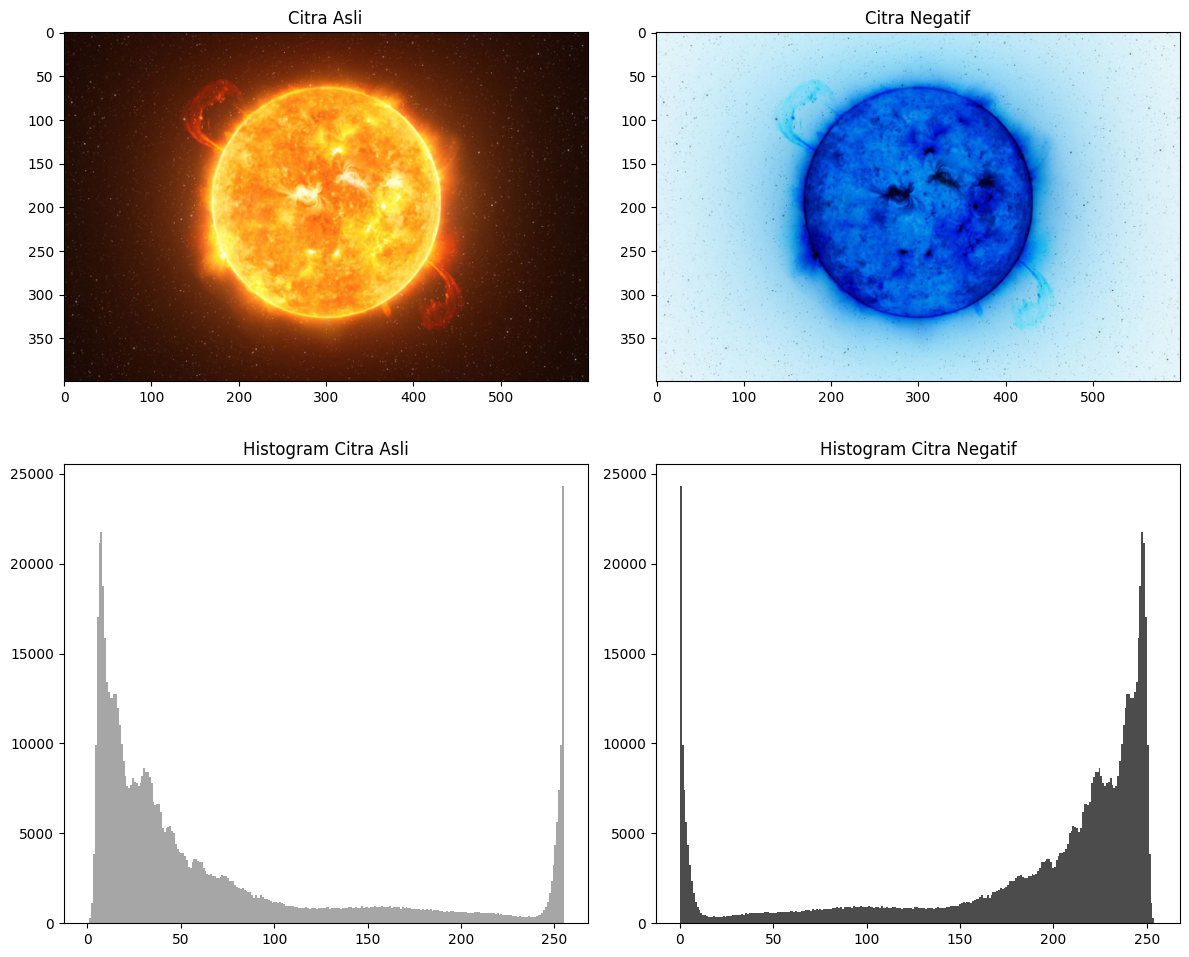

In [53]:
# Formulasi matematis pembalikan nilai kontras intensitas
img_negative = 255 - img1_resize

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img1_resize)
axes[0, 0].set_title("Citra Asli")
axes[0, 1].imshow(img_negative)
axes[0, 1].set_title("Citra Negatif")

# Distribusi statistik histogram pixel
axes[1, 0].hist(img1_resize.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title("Histogram Citra Asli")
axes[1, 1].hist(img_negative.ravel(), bins=256, color='black', alpha=0.7)
axes[1, 1].set_title("Histogram Citra Negatif")
plt.tight_layout()
plt.show()

BAGIAN E: Transformasi Logaritmik (Pemetaan Non-linear)

/tmp/ipykernel_1489/2439818664.py:3: RuntimeWarning: overflow encountered in scalar add
  c_log = 255 / np.log10(1 + r_max)
/tmp/ipykernel_1489/2439818664.py:3: RuntimeWarning: divide by zero encountered in log10
  c_log = 255 / np.log10(1 + r_max)


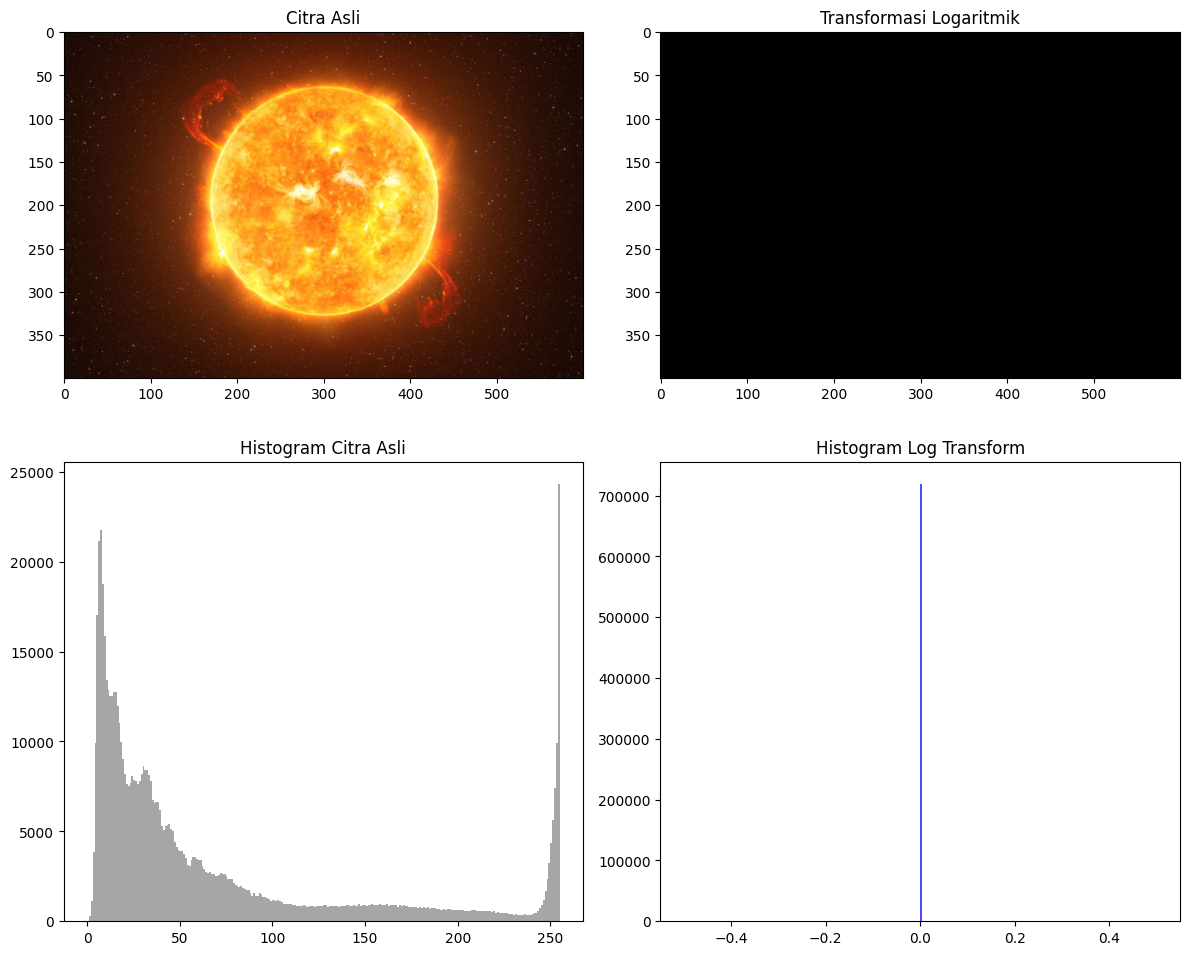

Batas Atas/Bawah Pixel Citra Asli -> Min: 0, Max: 255
Batas Atas/Bawah Pixel Hasil Log  -> Min: 0, Max: 0


In [54]:
# Kalkulasi konstanta penyeimbang skala dinamis c
r_max = np.max(img1_resize)
c_log = 255 / np.log10(1 + r_max)

# Operasi logaritma berbasis float64 untuk presisi, lalu dikembalikan ke uint8
img_log = c_log * np.log10(img1_resize.astype(np.float64) + 1)
img_log = np.array(img_log, dtype=np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img1_resize)
axes[0, 0].set_title("Citra Asli")
axes[0, 1].imshow(img_log)
axes[0, 1].set_title("Transformasi Logaritmik")

axes[1, 0].hist(img1_resize.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title("Histogram Citra Asli")
axes[1, 1].hist(img_log.ravel(), bins=256, color='blue', alpha=0.7)
axes[1, 1].set_title("Histogram Log Transform")
plt.tight_layout()
plt.show()

print(f"Batas Atas/Bawah Pixel Citra Asli -> Min: {img1_resize.min()}, Max: {img1_resize.max()}")
print(f"Batas Atas/Bawah Pixel Hasil Log  -> Min: {img_log.min()}, Max: {img_log.max()}")

BAGIAN F: Transformasi Gamma (Power-Law Correction)

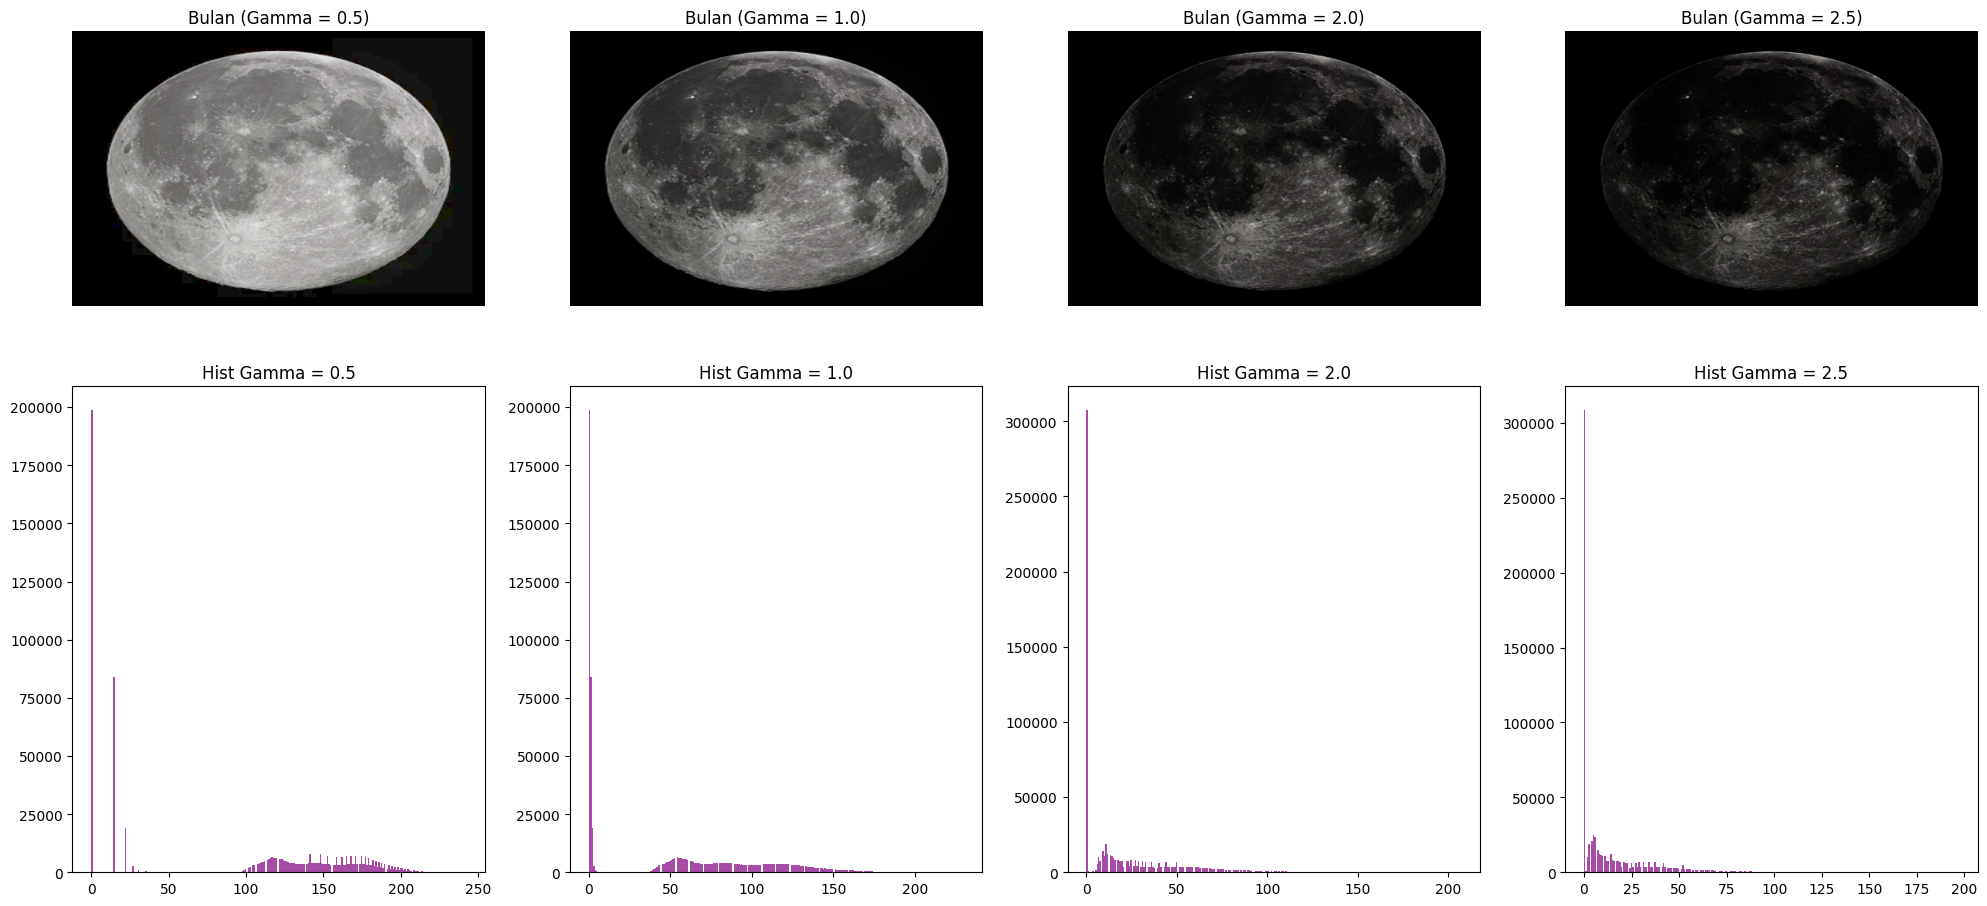

In [55]:
# Menguji variasi nilai kecerahan pada gambar bulan
gammas = [0.5, 1.0, 2.0, 2.5]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Normalisasi data ke rentang floating-point [0, 1]
img_normalized = img2_resize / 255.0

for idx, g in enumerate(gammas):
    img_gamma_res = np.uint8(np.power(img_normalized, g) * 255)

    # Menampilkan visualisasi tekstur permukaan bulan
    axes[0, idx].imshow(img_gamma_res)
    axes[0, idx].set_title(f"Bulan (Gamma = {g})")
    axes[0, idx].axis('off')

    # Menampilkan kurva penyebaran histogram
    axes[1, idx].hist(img_gamma_res.ravel(), bins=256, color='purple', alpha=0.7)
    axes[1, idx].set_title(f"Hist Gamma = {g}")

plt.tight_layout()
plt.show()